In [1]:
from numpy.random import randint
from numpy.random import rand
import numpy as np
import matplotlib.pyplot as plt
import random

## Definition of single-objective functions

In [2]:
def himmelbau(x1,x2):
    return (x1 ** 2 + x2 - 11) ** 2 + (x1 + x2 ** 2 - 7) ** 2

In [3]:
def three_hump_camel(x1,x2):
    return 2*x1**2-1.05*x1**4+(x1**6)/6+x1*x2+x2*2

# Task 2.1 – Generation of random solutions

## Task 2.1.1 - Generation of random fitness values for Himmelblau’s function 

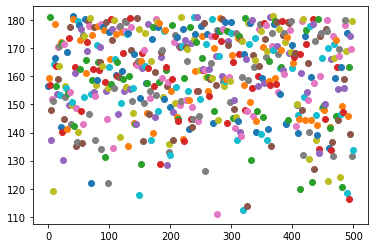

In [4]:
# Generate 500 random number
for i in range (0,500):
    np.random.seed(i)
    #random values between -1 and 1
    x1=np.random.uniform(-1,1)
    x2=np.random.uniform(-1,1)
    f = himmelbau(x1,x2)
    plt.scatter(i,f)
plt.show()

## Task 2.1.1 - Generation of random fitness values for Three-hump camel function

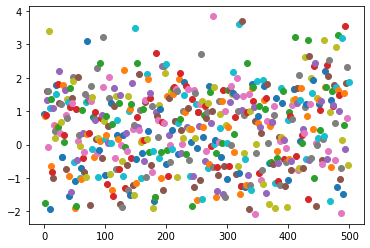

In [5]:
# Generate 500 random number
for i in range (0,500):
    np.random.seed(i)
    #random values between -1 and 1
    x1=np.random.uniform(-1,1)
    x2=np.random.uniform(-1,1)
    f = three_hump_camel(x1,x2)
    plt.scatter(i,f)
plt.show()

# Task 2.2 – Algorithm implementation 

## Task 2.2.1 - optimizing Himmelblau’s function

In [6]:
# objective function
def objective(x,f):
    if(f==0):
        return himmelbau(x[0],x[1])
    else:
        return three_hump_camel(x[0],x[1])

## uniform crossover

In [7]:
# crossover two parents to create two children
def crossover(p1, p2, r_cross):
    # children are copies of parents by default
    c1, c2 = p1.copy(), p2.copy()
    # check for recombination
    if rand() < r_cross:
        # perform uniform crossover
        pt = 16
        # perform crossover
        c1 = p1[:pt] + p2[pt:]
        c2 = p2[:pt] + p1[pt:]
    return [c1, c2]

## additive Gaussian mutation.

In [8]:
# mutation operator
def mutation(bitstring, r_mut):
    for i in range(len(bitstring)):
        # check for a mutation
        if rand() < r_mut:
            # flip the bit
            #bitstring[i] = 1 - bitstring[i]
            #bitstring_int=int(str(bitstring), 2)
            bitstring_int=int(''.join(str(i) for i in bitstring), 2)
            sample_from_gaussian= np.random.normal(0, 0.1, 1)
            bitstring_int=bitstring_int+sample_from_gaussian*200
            # print(bitstring_int)
            bitstring=format(np.int(bitstring_int), "032b")
                                  

# Selection 

In [9]:
#selection
def selection(pop, scores, k=3):
    # first random selection
    selection_ix = randint(len(pop))
    for ix in randint(0, len(pop), k-1):
        # check if better (e.g. perform a tournament)
        if scores[ix] < scores[selection_ix]:
            selection_ix = ix
    return pop[selection_ix]

In [10]:
# decode bitstring to numbers Sample from gaussian distribution is added in this function
def decode(bounds, n_bits, bitstring):
    decoded = list()
    largest = 2**n_bits
    for i in range(len(bounds)):
        # extract the substring
        start, end = i * n_bits, (i * n_bits)+n_bits
        substring = bitstring[start:end]
        # convert bitstring to a string of chars
        chars = ''.join([str(s) for s in substring])
        # convert string to integer
        integer = int(chars, 2)
        # scale integer to desired range
        value = bounds[i][0] + (integer/largest) * (bounds[i][1] - bounds[i][0])
        # store
        decoded.append(value)
    return decoded 

In [11]:
# genetic algorithm
def genetic_algorithm(objective,f, bounds, n_bits, n_iter, n_pop, r_cross, r_mut):
    # initial population of random bitstring
    pop = [randint(0, 2, n_bits*len(bounds)).tolist() for _ in range(n_pop)]
    # keep track of best solution
    best, best_eval = 0, objective(decode(bounds, n_bits, pop[0]),f)
    # enumerate generations
    for gen in range(n_iter):
        # decode population
        decoded = [decode(bounds, n_bits, p) for p in pop]
        # evaluate all candidates in the population
        scores = [objective(d,f) for d in decoded]
        # check for new best solution
        for i in range(n_pop):
            if scores[i] < best_eval:
                best, best_eval = pop[i], scores[i]
        # select parents
        selected = [selection(pop, scores) for _ in range(n_pop)]
        # create the next generation
        children = list()
        for i in range(0, n_pop, 2):
            # get selected parents in pairs
            p1, p2 = selected[i], selected[i+1]
            # crossover and mutation
            for c in crossover(p1, p2, r_cross):
                # mutation
                mutation(c, r_mut)
                # store for next generation
                children.append(c)
        # replace population
        pop = children
    return [best, best_eval]

In [12]:
# define range for input
bounds = [[-5.0, 5.0], [-5.0, 5.0]]
# define the total iterations
n_iter = 600
# bits per variable
n_bits = 32
# define the population size
n_pop = 300
# crossover rate
r_cross = 0.9
# mutation rate
r_mut = 1.0 / (float(n_bits) * len(bounds))
# perform the genetic algorithm search
f=0
best, score = genetic_algorithm(objective,f, bounds, n_bits, n_iter, n_pop, r_cross, r_mut)
print('Done!')
decoded = decode(bounds, n_bits, best)
print('f(%s) = %f' % (decoded, score))

C:\Users\user\AppData\Local\Temp/ipykernel_18984/1786132799.py:13: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  bitstring=format(np.int(bitstring_int), "032b")


Done!
f([-2.7741297404281795, 3.124588921200484]) = 0.032384


# Task 2.3 – Visualisation of results

## Modify  optimiser to record the average fitness at each generation

In [13]:
# genetic algorithm
def genetic_algorithm(objective,f, bounds, n_bits, n_iter, n_pop, r_cross, r_mut):
    avg_fitness=[]
    # initial population of random bitstring
    pop = [randint(0, 2, n_bits*len(bounds)).tolist() for _ in range(n_pop)]
    # keep track of best solution
    best, best_eval = 0, objective(decode(bounds, n_bits, pop[0]),f)
    # enumerate generations
    for gen in range(n_iter):
        # decode population
        decoded = [decode(bounds, n_bits, p) for p in pop]
        # evaluate all candidates in the population
        scores = [objective(d,f) for d in decoded]
        # check for new best solution
        for i in range(n_pop):
            if scores[i] < best_eval:
                best, best_eval = pop[i], scores[i]
                avg_fitness.append(scores[i])
                #print(">%d, new best f(%s) = %.3f" % (gen,  decoded[i], scores[i]))
        # select parents
        selected = [selection(pop, scores) for _ in range(n_pop)]
        # create the next generation
        children = list()
        for i in range(0, n_pop, 2):
            # get selected parents in pairs
            p1, p2 = selected[i], selected[i+1]
            # crossover and mutation
            for c in crossover(p1, p2, r_cross):
                # mutation
                mutation(c, r_mut)
                # store for next generation
                children.append(c)
        # replace population
        pop = children
    return [best, best_eval,avg_fitness]

C:\Users\user\AppData\Local\Temp/ipykernel_18984/1786132799.py:13: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  bitstring=format(np.int(bitstring_int), "032b")


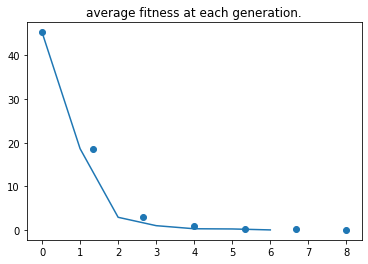

In [14]:
# define range for input
bounds = [[-5.0, 5.0], [-5.0, 5.0]]
# define the total iterations
n_iter = 600
# bits per variable
n_bits = 32
# define the population size
n_pop = 300
# crossover rate
r_cross = 0.9
# mutation rate
r_mut = 1.0 / (float(n_bits) * len(bounds))
# perform the genetic algorithm search
f=0
best, score ,avg_fitness= genetic_algorithm(objective,f, bounds, n_bits, n_iter, n_pop, r_cross, r_mut)
plt.plot(avg_fitness)
x=np.linspace(0, len(avg_fitness)+1, num=len(avg_fitness))
plt.scatter(x,avg_fitness)
plt.title("average fitness at each generation.")
plt.show()